In [1]:
import sys
import os
import time
import math
import platform
import csv
from pathlib import Path

import numpy as np

root = Path.cwd()
parents = [root, root.parent, root.parent.parent]
for base in parents:
    if (base / "efgp_eigenpro_py").exists():
        sys.path.insert(0, str(base))
        break
else:
    raise RuntimeError("cannot find efgp_eigenpro_py from current path")

from efgp_eigenpro_py.efgp_solver import EFGPSolver, PrecomputeState
from efgp_eigenpro_py.discretization import choose_grid_params, basis_weights, generate_multi_index
from efgp_eigenpro_py.nufft_ops import nufft1d1, nufft2d1, nufft3d1
from efgp_eigenpro_py.kernels import make_squared_exponential
from efgp_eigenpro_py.eigenspace import estimate_top_eigenspace
from efgp_eigenpro_py.eigenpro_precond import build_preconditioner
from efgp_eigenpro_py import benchmark as bm

np.set_printoptions(precision=4, suppress=True)

RUN_T1 = True
RUN_T2 = True
RUN_T3 = True
RUN_RICHARDSON = False

RUN_DENSE_KRR = True
RUN_KERNEL_CG = True
RUN_NYSTROM = True
RUN_NYSTROM_LARGE = False

RUN_T1_LARGE = True
RUN_T2_LARGE = True
RUN_T3_LARGE = True
RUN_T1_LARGE_Q20 = False
RUN_T2_LARGE_N1E7 = False
RUN_T3_LARGE_N3E6 = False

MAX_DENSE_N = 3000
MAX_DENSE_M = 5000
MAX_KERNEL_CG_N_1D = 30000
MAX_KERNEL_CG_N_2D = 10000

# small anchor for dense KRR
DENSE_KRR_N_LIST_T1 = [1000]
DENSE_KRR_N_LIST_T2 = [1000]
DENSE_KRR_N_LIST_T3 = [3000]

# medium representative points for kernel CG
KERNEL_CG_N_LIST_T1 = [10000]
KERNEL_CG_N_LIST_T2 = [10000]
KERNEL_CG_N_LIST_T3 = [10000]

# Nyström baseline only at small/medium points
NYSTROM_N_LIST_T1 = [10000]
NYSTROM_N_LIST_T2 = [10000]
NYSTROM_N_LIST_T3 = [10000]

# large-scale extensions (overlap points already in base lists)
T1_LARGE_N_LIST = [1000000, 3000000, 10000000]
T2_LARGE_N_LIST = [1000000, 3000000, 10000000]
T3_LARGE_N_LIST = [1000000, 3000000]

NYSTROM_M_DEFAULT = 1000
NYSTROM_M_LARGE = 1000
NYSTROM_MAX_ENTRIES = 20000000  # N * m

TOP_Q = 10

OUTPUT_CSV = "benchmark_gpu_prep_results.csv"


In [2]:
have_plot = False
plt = None


def enable_plotting():
    global have_plot, plt
    try:
        import importlib
        plt = importlib.import_module("matplotlib.pyplot")
        have_plot = True
        print("matplotlib enabled")
    except BaseException as exc:
        have_plot = False
        plt = None
        print("matplotlib not usable, skip plots:", exc)


def true_func_1d(x):
    x = np.asarray(x).reshape(-1)
    return np.sin(2 * np.pi * x) + 0.3 * np.cos(6 * np.pi * x)


def true_func_2d(x):
    x = np.asarray(x)
    return (
        np.sin(2 * np.pi * x[:, 0])
        + 0.5 * np.cos(2 * np.pi * x[:, 1])
        + 0.2 * np.sin(2 * np.pi * (x[:, 0] + x[:, 1]))
    )


def make_dataset(dim, n, func, noise=0.02, seed=0):
    return bm.make_dataset(dim, n, func, noise=noise, seed=seed)


def make_clustered_2d(n, seed=0):
    return bm.make_clustered_2d(n, seed=seed)


def make_test_set(dim, n, func, seed=0):
    return bm.make_test_set(dim, n, func, seed=seed)


def compute_rmse(yhat, ytrue):
    return bm.compute_rmse(yhat, ytrue)


In [3]:
def get_cpu_name():
    return bm.get_cpu_name()


def get_num_threads():
    return bm.get_num_threads()


def get_rss_mb():
    return bm.get_rss_mb()


def bytes_per_vector_m(M):
    return bm.bytes_per_vector_m(M)


def bytes_per_vector_n(N):
    return bm.bytes_per_vector_n(N)


CPU_NAME = get_cpu_name()
NUM_THREADS = get_num_threads()


In [4]:
def kernel_matrix_dense(x, kernel):
    return bm.kernel_matrix_dense(x, kernel)


def kernel_matvec_block(x, v, kernel, block_size=256):
    return bm.kernel_matvec_block(x, v, kernel, block_size=block_size)


def kernel_predict_block(x_train, alpha, x_eval, kernel, block_size=256):
    return bm.kernel_predict_block(x_train, alpha, x_eval, kernel, block_size=block_size)


def cg_basic(matvec, b, tol=1e-6, maxiter=20000):
    return bm.cg_basic(matvec, b, tol=tol, maxiter=maxiter)


def kernel_cg_solve(x_train, y_train, kernel, reg_lambda, tol=1e-6, maxiter=20000, block_size=256):
    return bm.kernel_cg_solve(
        x_train,
        y_train,
        kernel,
        reg_lambda,
        tol=tol,
        maxiter=maxiter,
        block_size=block_size,
    )


In [5]:
def nystrom_krr(x_train, y_train, x_test, kernel, reg_lambda, m, seed=0, block_size=256):
    return bm.nystrom_krr(
        x_train,
        y_train,
        x_test,
        kernel,
        reg_lambda,
        m=m,
        seed=seed,
        block_size=block_size,
        max_entries=NYSTROM_MAX_ENTRIES,
    )


In [7]:
def dense_multi_index(m, dim):
    return bm.generate_multi_index(m, dim)


def build_dense_phi(solver, x, state):
    return bm.build_dense_phi(solver, x, state)


def build_dense_A_rhs(solver, x, y, state):
    return bm.build_dense_A_rhs(solver, x, y, state)


def precompute_with_timing(solver, x, y):
    return bm.precompute_with_timing(solver, x, y)


def build_precond_from_state(solver, state, top_q):
    return bm.build_precond_from_state(solver, state, top_q)


def pcg_solve(matvec, b, tol=1e-10, maxiter=20000, precond=None):
    x, it_count, relres, hist = bm.pcg_solve(matvec, b, tol=tol, maxiter=maxiter, precond=precond, store_history=False)
    return x, it_count, float(relres)


def richardson_solve(matvec, b, eta, tol=1e-8, maxiter=20000, precond=None):
    x, it, relres, hist = bm.richardson_solve(matvec, b, eta=eta, tol=tol, maxiter=maxiter, precond=precond, store_history=False)
    return x, it, float(relres)


def spectral_metrics(A_dense, eigpairs, top_q):
    return bm.spectral_metrics_dense(A_dense, eigpairs, top_q)


def run_efgp_case(task_id, dim, x_train, y_train, x_test, y_test, kernel, reg_lambda, eps, top_q, krr_pred=None):
    return bm.run_efgp_case(
        task_id=task_id,
        dim=dim,
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        kernel=kernel,
        reg_lambda=reg_lambda,
        eps=eps,
        nufft_tol=1e-12,
        top_q=top_q,
        tol=1e-10,
        maxiter=20000,
        solver_type="pcg",
        eta=None,
        compute_dense=True,
        dense_max_m=MAX_DENSE_M,
        dense_max_n=MAX_DENSE_N,
        krr_pred=krr_pred,
        store_history=False,
    )


In [8]:
CSV_COLUMNS = bm.BENCHMARK_COLUMNS

RESULTS = []


def append_row(row):
    RESULTS.append(row)
    if OUTPUT_CSV is None:
        return
    file_exists = os.path.exists(OUTPUT_CSV)
    with open(OUTPUT_CSV, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_COLUMNS)
        if not file_exists:
            writer.writeheader()
        writer.writerow({k: row.get(k) for k in CSV_COLUMNS})


In [9]:
def run_dense_krr(task_id, dim, x_train, y_train, x_test, y_test, kernel, reg_lambda):
    return bm.run_dense_krr(
        task_id,
        dim,
        x_train,
        y_train,
        x_test,
        y_test,
        kernel,
        reg_lambda,
    )


def run_kernel_cg(task_id, dim, x_train, y_train, x_test, y_test, kernel, reg_lambda):
    return bm.run_kernel_cg(
        task_id,
        dim,
        x_train,
        y_train,
        x_test,
        y_test,
        kernel,
        reg_lambda,
    )


def run_nystrom(task_id, dim, x_train, y_train, x_test, y_test, kernel, reg_lambda, m):
    return bm.run_nystrom(
        task_id,
        dim,
        x_train,
        y_train,
        x_test,
        y_test,
        kernel,
        reg_lambda,
        m=m,
        max_entries=NYSTROM_MAX_ENTRIES,
    )


def run_task_t1():
    task_id = "T1_1d_uniform"
    N_list = [1000, 10000, 100000, 300000, 1000000]
    for n in N_list:
        print("T1 N=", n)
        x_train, y_train = make_dataset(1, n, true_func_1d, noise=0.02, seed=0)
        x_test, y_test = make_test_set(1, 2000, true_func_1d, seed=1)
        kernel = make_squared_exponential(lengthscale=0.2, dim=1, variance=1.0)
        reg_lambda = 1e-3
        eps = 1e-4

        krr_pred = None
        if RUN_DENSE_KRR and (n in DENSE_KRR_N_LIST_T1):
            row_krr, krr_pred = run_dense_krr(task_id, 1, x_train, y_train, x_test, y_test, kernel, reg_lambda)
            append_row(row_krr)

        if RUN_KERNEL_CG and (n in KERNEL_CG_N_LIST_T1):
            row_cg = run_kernel_cg(task_id, 1, x_train, y_train, x_test, y_test, kernel, reg_lambda)
            append_row(row_cg)

        if RUN_NYSTROM and (n in NYSTROM_N_LIST_T1):
            m = min(NYSTROM_M_DEFAULT, n)
            row_nys = run_nystrom(task_id, 1, x_train, y_train, x_test, y_test, kernel, reg_lambda, m=m)
            if row_nys is not None:
                append_row(row_nys)

        rows = run_efgp_case(task_id, 1, x_train, y_train, x_test, y_test, kernel, reg_lambda, eps, TOP_Q, krr_pred=krr_pred)
        for row in rows:
            append_row(row)

    if RUN_T1_LARGE:
        top_q_list = [0, 10, 20] if RUN_T1_LARGE_Q20 else [0, 10]
        for n in T1_LARGE_N_LIST:
            print("T1 large N=", n)
            x_train, y_train = make_dataset(1, n, true_func_1d, noise=0.02, seed=0)
            x_test, y_test = make_test_set(1, 2000, true_func_1d, seed=1)
            kernel = make_squared_exponential(lengthscale=0.2, dim=1, variance=1.0)
            reg_lambda = 1e-3
            eps = 1e-4

            if RUN_NYSTROM and RUN_NYSTROM_LARGE:
                m = min(NYSTROM_M_LARGE, n)
                row_nys = run_nystrom(task_id + "_large", 1, x_train, y_train, x_test, y_test, kernel, reg_lambda, m=m)
                if row_nys is not None:
                    append_row(row_nys)

            for q in top_q_list:
                rows = run_efgp_case(task_id + "_large", 1, x_train, y_train, x_test, y_test, kernel, reg_lambda, eps, q, krr_pred=None)
                for row in rows:
                    append_row(row)


def run_task_t2():
    task_id = "T2_2d_uniform"
    N_list = [1000, 10000, 30000, 100000, 300000]
    for n in N_list:
        print("T2 N=", n)
        x_train, y_train = make_dataset(2, n, true_func_2d, noise=0.02, seed=2)
        x_test, y_test = make_test_set(2, 500, true_func_2d, seed=3)
        kernel = make_squared_exponential(lengthscale=0.2, dim=2, variance=1.0)
        reg_lambda = 1e-3
        eps = 1e-4

        krr_pred = None
        if RUN_DENSE_KRR and (n in DENSE_KRR_N_LIST_T2):
            row_krr, krr_pred = run_dense_krr(task_id, 2, x_train, y_train, x_test, y_test, kernel, reg_lambda)
            append_row(row_krr)

        if RUN_KERNEL_CG and (n in KERNEL_CG_N_LIST_T2):
            row_cg = run_kernel_cg(task_id, 2, x_train, y_train, x_test, y_test, kernel, reg_lambda)
            append_row(row_cg)

        if RUN_NYSTROM and (n in NYSTROM_N_LIST_T2):
            m = min(NYSTROM_M_DEFAULT, n)
            row_nys = run_nystrom(task_id, 2, x_train, y_train, x_test, y_test, kernel, reg_lambda, m=m)
            if row_nys is not None:
                append_row(row_nys)

        rows = run_efgp_case(task_id, 2, x_train, y_train, x_test, y_test, kernel, reg_lambda, eps, TOP_Q, krr_pred=krr_pred)
        for row in rows:
            append_row(row)

    if RUN_T2_LARGE:
        top_q_list = [0, 20, 40]
        n_list = [n for n in T2_LARGE_N_LIST if (RUN_T2_LARGE_N1E7 or n < 10000000)]
        for n in n_list:
            print("T2 large N=", n)
            x_train, y_train = make_dataset(2, n, true_func_2d, noise=0.02, seed=2)
            x_test, y_test = make_test_set(2, 500, true_func_2d, seed=3)
            kernel = make_squared_exponential(lengthscale=0.2, dim=2, variance=1.0)
            reg_lambda = 1e-3
            eps = 1e-4

            if RUN_NYSTROM and RUN_NYSTROM_LARGE:
                m = min(NYSTROM_M_LARGE, n)
                row_nys = run_nystrom(task_id + "_large", 2, x_train, y_train, x_test, y_test, kernel, reg_lambda, m=m)
                if row_nys is not None:
                    append_row(row_nys)

            for q in top_q_list:
                rows = run_efgp_case(task_id + "_large", 2, x_train, y_train, x_test, y_test, kernel, reg_lambda, eps, q, krr_pred=None)
                for row in rows:
                    append_row(row)

    # small top_q sweep at two sizes
    sweep_n_list = [10000, 100000]
    sweep_top_q = [10, 20, 40]
    for n in sweep_n_list:
        print("T2 top_q sweep N=", n)
        x_train, y_train = make_dataset(2, n, true_func_2d, noise=0.02, seed=2)
        x_test, y_test = make_test_set(2, 500, true_func_2d, seed=3)
        kernel = make_squared_exponential(lengthscale=0.2, dim=2, variance=1.0)
        reg_lambda = 1e-3
        eps = 1e-4
        for q in sweep_top_q:
            rows = run_efgp_case(
                task_id + "_topq_sweep",
                2,
                x_train,
                y_train,
                x_test,
                y_test,
                kernel,
                reg_lambda,
                eps,
                q,
                krr_pred=None,
            )
            for row in rows:
                append_row(row)


def run_task_t3():
    task_id = "T3_2d_clustered"
    N_list = [3000, 10000, 30000, 100000]
    for n in N_list:
        print("T3 N=", n)
        x_train = make_clustered_2d(n, seed=5)
        y_train = true_func_2d(x_train) + 0.02 * np.random.default_rng(6).standard_normal(n)
        x_test, y_test = make_test_set(2, 500, true_func_2d, seed=7)
        kernel = make_squared_exponential(lengthscale=0.2, dim=2, variance=1.0)
        reg_lambda = 1e-3
        eps = 1e-4

        krr_pred = None
        if RUN_DENSE_KRR and (n in DENSE_KRR_N_LIST_T3):
            row_krr, krr_pred = run_dense_krr(task_id, 2, x_train, y_train, x_test, y_test, kernel, reg_lambda)
            append_row(row_krr)

        if RUN_KERNEL_CG and (n in KERNEL_CG_N_LIST_T3):
            row_cg = run_kernel_cg(task_id, 2, x_train, y_train, x_test, y_test, kernel, reg_lambda)
            append_row(row_cg)

        rows = run_efgp_case(task_id, 2, x_train, y_train, x_test, y_test, kernel, reg_lambda, eps, TOP_Q, krr_pred=krr_pred)
        for row in rows:
            append_row(row)

    if RUN_T3_LARGE:
        top_q_list = [0, 20]
        n_list = [n for n in T3_LARGE_N_LIST if (RUN_T3_LARGE_N3E6 or n < 3000000)]
        for n in n_list:
            print("T3 large N=", n)
            x_train = make_clustered_2d(n, seed=5)
            y_train = true_func_2d(x_train) + 0.02 * np.random.default_rng(6).standard_normal(n)
            x_test, y_test = make_test_set(2, 500, true_func_2d, seed=7)
            kernel = make_squared_exponential(lengthscale=0.2, dim=2, variance=1.0)
            reg_lambda = 1e-3
            eps = 1e-4

            if RUN_NYSTROM and RUN_NYSTROM_LARGE:
                m = min(NYSTROM_M_LARGE, n)
                row_nys = run_nystrom(task_id + "_large", 2, x_train, y_train, x_test, y_test, kernel, reg_lambda, m=m)
                if row_nys is not None:
                    append_row(row_nys)

            for q in top_q_list:
                rows = run_efgp_case(task_id + "_large", 2, x_train, y_train, x_test, y_test, kernel, reg_lambda, eps, q, krr_pred=None)
                for row in rows:
                    append_row(row)


In [37]:
enable_plotting()

if RUN_T1:
    run_task_t1()

if RUN_T2:
    run_task_t2()

if RUN_T3:
    run_task_t3()

print("done, results in", OUTPUT_CSV)


matplotlib enabled
T1 N= 1000


T1 N= 10000
T1 N= 100000
T1 N= 300000
T1 N= 1000000
T1 large N= 1000000
T1 large N= 3000000
T1 large N= 10000000
T2 N= 1000
T2 N= 10000
T2 N= 30000
T2 N= 100000
T2 N= 300000
T2 large N= 1000000
T2 large N= 3000000
T2 top_q sweep N= 10000
T2 top_q sweep N= 100000
T3 N= 3000
T3 N= 10000
T3 N= 30000
T3 N= 100000
T3 large N= 1000000
done, results in benchmark_gpu_prep_results.csv


matplotlib enabled


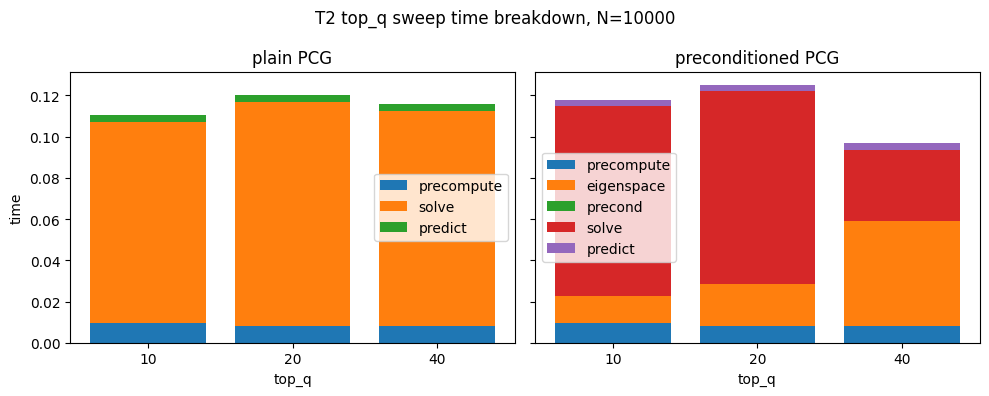

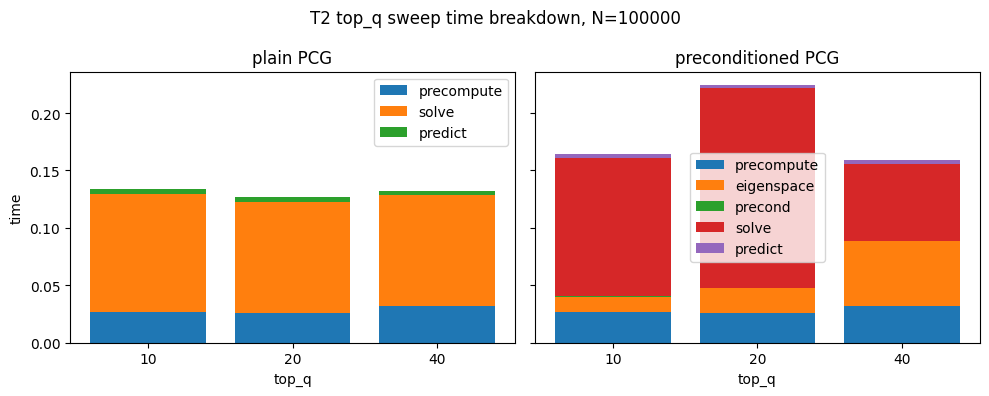

In [38]:
# visualize time breakdown for T2 top_q sweep
CSV_PATH = OUTPUT_CSV

if not os.path.exists(CSV_PATH):
    print("csv not found:", CSV_PATH)
else:
    enable_plotting()
    if not have_plot:
        print("matplotlib not enabled, skip plots")
    else:
        import csv as _csv
        from collections import defaultdict

        def _to_float(v):
            if v is None:
                return None
            s = str(v).strip()
            if s == "" or s.lower() == "none":
                return None
            try:
                return float(s)
            except Exception:
                return None

        def _to_int(v):
            if v is None:
                return None
            s = str(v).strip()
            if s == "" or s.lower() == "none":
                return None
            try:
                return int(float(s))
            except Exception:
                return None

        data = defaultdict(lambda: defaultdict(dict))
        with open(CSV_PATH, "r", newline="") as f:
            reader = _csv.DictReader(f)
            for row in reader:
                if row.get("task_id") != "T2_2d_uniform_topq_sweep":
                    continue
                method = row.get("method")
                if method not in ("efgp_plain_pcg", "efgp_prec_pcg"):
                    continue
                n = _to_int(row.get("N"))
                q = _to_int(row.get("top_q"))
                if n is None or q is None:
                    continue
                data[method][n][q] = row

        if not data:
            print("no rows found for T2_2d_uniform_topq_sweep")
        else:
            n_list = sorted(set(list(data["efgp_plain_pcg"].keys()) + list(data["efgp_prec_pcg"].keys())))
            for n in n_list:
                qs = sorted(set(list(data["efgp_plain_pcg"].get(n, {}).keys()) + list(data["efgp_prec_pcg"].get(n, {}).keys())))
                if not qs:
                    continue

                fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
                fig.suptitle("T2 top_q sweep time breakdown, N=" + str(n))

                # plain
                ax = axes[0]
                comps = [
                    ("precompute", "time_precompute_total"),
                    ("solve", "time_solve_plain"),
                    ("predict", "time_predict_plain"),
                ]
                bottom = np.zeros(len(qs))
                for label, key in comps:
                    vals = []
                    for q in qs:
                        row = data["efgp_plain_pcg"].get(n, {}).get(q, {})
                        vals.append(_to_float(row.get(key)) or 0.0)
                    vals = np.array(vals)
                    ax.bar(np.arange(len(qs)), vals, bottom=bottom, label=label)
                    bottom = bottom + vals
                ax.set_title("plain PCG")
                ax.set_xlabel("top_q")
                ax.set_xticks(np.arange(len(qs)))
                ax.set_xticklabels([str(q) for q in qs])
                ax.set_ylabel("time")
                ax.legend()

                # precond
                ax = axes[1]
                comps = [
                    ("precompute", "time_precompute_total"),
                    ("eigenspace", "time_eigenspace"),
                    ("precond", "time_precond_build"),
                    ("solve", "time_solve_prec"),
                    ("predict", "time_predict_prec"),
                ]
                bottom = np.zeros(len(qs))
                for label, key in comps:
                    vals = []
                    for q in qs:
                        row = data["efgp_prec_pcg"].get(n, {}).get(q, {})
                        vals.append(_to_float(row.get(key)) or 0.0)
                    vals = np.array(vals)
                    ax.bar(np.arange(len(qs)), vals, bottom=bottom, label=label)
                    bottom = bottom + vals
                ax.set_title("preconditioned PCG")
                ax.set_xlabel("top_q")
                ax.set_xticks(np.arange(len(qs)))
                ax.set_xticklabels([str(q) for q in qs])
                ax.legend()

                plt.tight_layout()
                plt.show()


matplotlib enabled
dense_total= 0.10163519997149706 dense_r2= 0.999999918809379 dense_rmse= 0.00022208436265829478 dense_mae= 0.00016935022779714415
N= 1000000 plain_total= 1.194767399923876 plain_it= 3554 plain_rr= 6.76163390808571e-11 plain_r2= 0.9999999188182245 plain_rmse= 0.00022207226471085604 plain_mae= 0.00016933880005536508 plain_converged= True
top_q, time_precompute, time_eigenspace, time_precond, time_solve, time_predict, time_total, it_prec, rr_prec, r2_prec, rmse_prec, mae_prec, converged
10 0.2601453000679612 0.021425100043416023 8.479994721710682e-05 0.3960343000944704 0.003251299960538745 0.6809408001136035 1860 9.572665268159644e-11 0.9999999188209496 0.00022206853738097442 0.00016933461231564495
20 0.2601453000679612 0.02119600004516542 7.54999928176403e-05 0.3765182001516223 0.0031587998382747173 0.6610938000958413 1056 9.35932541911679e-11 0.9999999188206401 0.0002220689606298393 0.00016933483763519858
40 0.2601453000679612 0.05010709981434047 7.010018453001976e-05

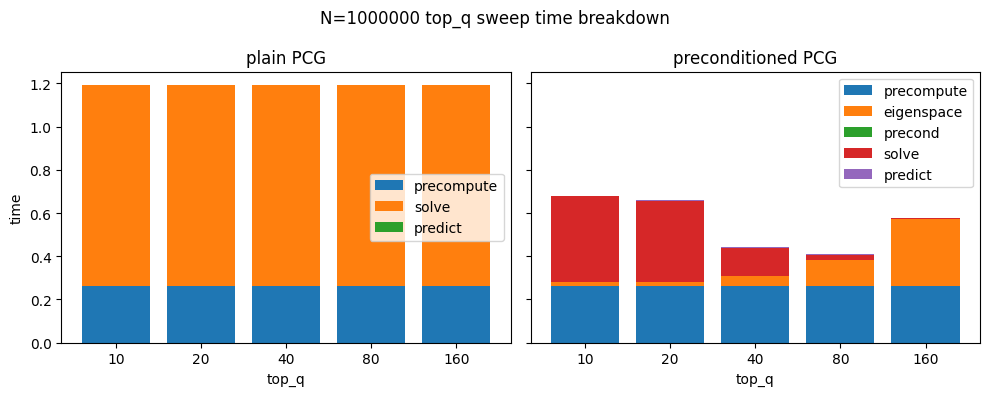

In [10]:
# quick top_q sweep for N=1 000 000 (2D uniform), no CSV update
enable_plotting()

N = 1000000
top_q_list = [10, 20, 40, 80, 160]
TOL = 1e-10
MAXITER = 50000

x_train, y_train = make_dataset(2, N, true_func_2d, noise=0.02, seed=2)
x_test, y_test = make_test_set(2, 500, true_func_2d, seed=3)

kernel = make_squared_exponential(lengthscale=0.2, dim=2, variance=1.0)
reg_lambda = 1e-3
eps = 1e-4

def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum((y_true - np.mean(y_true)) ** 2)
    if denom <= 0:
        return float("nan")
    num = np.sum((y_true - y_pred) ** 2)
    return float(1.0 - num / denom)


def mae_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))

solver = EFGPSolver(kernel, reg_lambda=reg_lambda, eps=eps, nufft_tol=1e-12)
state, pre_times = precompute_with_timing(solver, x_train, y_train)
matvec = lambda v: solver._apply_A(state, v)

# plain PCG (same for all q)
t_plain0 = time.perf_counter()
beta_plain, it_plain, rr_plain = pcg_solve(matvec, state.rhs, tol=TOL, maxiter=MAXITER, precond=None)
t_plain1 = time.perf_counter()

p_pred0 = time.perf_counter()
yhat_plain = solver.predict(x_test, beta_plain, state)
p_pred1 = time.perf_counter()

r2_plain = r2_score(y_test, yhat_plain)
rmse_plain = compute_rmse(yhat_plain, y_test)
mae_plain = mae_score(y_test, yhat_plain)
converged_plain = rr_plain < TOL

plain_times = {
    "precompute": pre_times["time_precompute_total"],
    "solve": t_plain1 - t_plain0,
    "predict": p_pred1 - p_pred0,
}
plain_total = plain_times["precompute"] + plain_times["solve"] + plain_times["predict"]

# direct dense solve (weight-space) when feasible
M = state.grid.mtot ** 2
if (M <= MAX_DENSE_M):
    d0 = time.perf_counter()
    A_dense = np.zeros((M, M), dtype=np.complex128)
    for j in range(M):
        e = np.zeros(M, dtype=np.complex128)
        e[j] = 1.0
        A_dense[:, j] = matvec(e)
    beta_dense = np.linalg.solve(A_dense, state.rhs)
    yhat_dense = solver.predict(x_test, beta_dense, state)
    d1 = time.perf_counter()

    r2_dense = r2_score(y_test, yhat_dense)
    rmse_dense = compute_rmse(yhat_dense, y_test)
    mae_dense = mae_score(y_test, yhat_dense)
    dense_total = d1 - d0

    print(
        "dense_total=", dense_total,
        "dense_r2=", r2_dense,
        "dense_rmse=", rmse_dense,
        "dense_mae=", mae_dense,
    )
else:
    print("dense solve skipped: M=", M, "max_M=", MAX_DENSE_M)

rows = []
for q in top_q_list:
    precond, eigpairs, mu, eig_time, precond_time, top_q_used = build_precond_from_state(solver, state, q)

    t_prec0 = time.perf_counter()
    beta_prec, it_prec, rr_prec = pcg_solve(
        matvec,
        state.rhs,
        tol=TOL,
        maxiter=MAXITER,
        precond=None if precond is None else precond.apply,
    )
    t_prec1 = time.perf_counter()

    pp0 = time.perf_counter()
    yhat_prec = solver.predict(x_test, beta_prec, state)
    pp1 = time.perf_counter()

    r2_prec = r2_score(y_test, yhat_prec)
    rmse_prec = compute_rmse(yhat_prec, y_test)
    mae_prec = mae_score(y_test, yhat_prec)
    converged_prec = rr_prec < TOL

    row = {
        "top_q": top_q_used,
        "time_precompute": pre_times["time_precompute_total"],
        "time_eigenspace": eig_time,
        "time_precond": precond_time,
        "time_solve": t_prec1 - t_prec0,
        "time_predict": pp1 - pp0,
        "time_total": pre_times["time_precompute_total"] + eig_time + precond_time + (t_prec1 - t_prec0) + (pp1 - pp0),
        "it_prec": it_prec,
        "rr_prec": rr_prec,
        "r2_prec": r2_prec,
        "rmse_prec": rmse_prec,
        "mae_prec": mae_prec,
        "converged": converged_prec,
    }
    rows.append(row)

print(
    "N=", N,
    "plain_total=", plain_total,
    "plain_it=", it_plain,
    "plain_rr=", rr_plain,
    "plain_r2=", r2_plain,
    "plain_rmse=", rmse_plain,
    "plain_mae=", mae_plain,
    "plain_converged=", converged_plain,
)
print("top_q, time_precompute, time_eigenspace, time_precond, time_solve, time_predict, time_total, it_prec, rr_prec, r2_prec, rmse_prec, mae_prec, converged")
for r in rows:
    print(
        r["top_q"],
        r["time_precompute"],
        r["time_eigenspace"],
        r["time_precond"],
        r["time_solve"],
        r["time_predict"],
        r["time_total"],
        r["it_prec"],
        r["rr_prec"],
        r["r2_prec"],
        r["rmse_prec"],
        r["mae_prec"],
    )

if have_plot:
    qs = [r["top_q"] for r in rows]
    x = np.arange(len(qs))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    fig.suptitle("N=" + str(N) + " top_q sweep time breakdown")

    # plain stacked (same for each q)
    ax = axes[0]
    base = np.zeros(len(qs))
    ax.bar(x, [plain_times["precompute"]] * len(qs), bottom=base, label="precompute")
    base = base + plain_times["precompute"]
    ax.bar(x, [plain_times["solve"]] * len(qs), bottom=base, label="solve")
    base = base + plain_times["solve"]
    ax.bar(x, [plain_times["predict"]] * len(qs), bottom=base, label="predict")
    ax.set_title("plain PCG")
    ax.set_xticks(x)
    ax.set_xticklabels([str(q) for q in qs])
    ax.set_xlabel("top_q")
    ax.set_ylabel("time")
    ax.legend()

    # precond stacked
    ax = axes[1]
    base = np.zeros(len(qs))
    vals = [r["time_precompute"] for r in rows]
    ax.bar(x, vals, bottom=base, label="precompute")
    base = base + np.array(vals)
    vals = [r["time_eigenspace"] for r in rows]
    ax.bar(x, vals, bottom=base, label="eigenspace")
    base = base + np.array(vals)
    vals = [r["time_precond"] for r in rows]
    ax.bar(x, vals, bottom=base, label="precond")
    base = base + np.array(vals)
    vals = [r["time_solve"] for r in rows]
    ax.bar(x, vals, bottom=base, label="solve")
    base = base + np.array(vals)
    vals = [r["time_predict"] for r in rows]
    ax.bar(x, vals, bottom=base, label="predict")
    ax.set_title("preconditioned PCG")
    ax.set_xticks(x)
    ax.set_xticklabels([str(q) for q in qs])
    ax.set_xlabel("top_q")
    ax.legend()

    plt.tight_layout()
    plt.show()


In [51]:
# EigenPro2-pytorch trial (local repo) aligned with 2D uniform sweep
EIGENPRO2_ROOT = Path("d:/NU/ML/EigenPro2-pytorch-master")

if not EIGENPRO2_ROOT.exists():
    print("EigenPro2 repo not found:", EIGENPRO2_ROOT)
else:
    sys.path.insert(0, str(EIGENPRO2_ROOT))
    try:
        import torch
        from eigenpro2.kernels import gaussian as ep2_gaussian
        from eigenpro2.models import KernelModel

        N_target = int(globals().get("N", 1000000))
        reuse = (
            "x_train" in globals()
            and "y_train" in globals()
            and "x_test" in globals()
            and "y_test" in globals()
            and isinstance(globals()["x_train"], np.ndarray)
            and isinstance(globals()["y_train"], np.ndarray)
            and isinstance(globals()["x_test"], np.ndarray)
            and isinstance(globals()["y_test"], np.ndarray)
            and globals()["x_train"].shape[0] == N_target
            and globals()["x_train"].shape[1] == 2
            and globals()["x_test"].shape[0] == 500
            and globals()["x_test"].shape[1] == 2
        )
        if reuse:
            x_train = globals()["x_train"]
            y_train = globals()["y_train"]
            x_test = globals()["x_test"]
            y_test = globals()["y_test"]
            print("EigenPro2 uses existing dataset from quick sweep")
        else:
            x_train, y_train = make_dataset(2, N_target, true_func_2d, noise=0.02, seed=2)
            x_test, y_test = make_test_set(2, 500, true_func_2d, seed=3)
            print("EigenPro2 regenerates dataset with fixed seeds")

        if torch.cuda.is_available():
            DEVICE = torch.device("cuda")
            DEV_MEM = torch.cuda.get_device_properties(DEVICE).total_memory // 1024**3 - 1
            print("EigenPro2 device=CUDA", torch.cuda.get_device_name(DEVICE), "mem_gb=", DEV_MEM)
        else:
            DEVICE = torch.device("cpu")
            DEV_MEM = 8
            print("EigenPro2 device=CPU")

        x_train_t = torch.as_tensor(x_train, dtype=torch.float32, device=DEVICE)
        y_train_t = torch.as_tensor(y_train.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
        x_test_t = torch.as_tensor(x_test, dtype=torch.float32, device=DEVICE)
        y_test_t = torch.as_tensor(y_test.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

        kernel_fn = lambda a, b: ep2_gaussian(a, b, bandwidth=0.2)
        model = KernelModel(kernel_fn, x_train_t, y_dim=1, device=DEVICE)

        max_epochs = 500
        chunk = 5
        patience = 3
        rel_tol = 1e-4
        no_improve = 0
        best_val = float("inf")
        total_epochs = 0

        n_subsamples = min(12000, N_target)
        top_q = 10

        t0 = time.perf_counter()
        while total_epochs < max_epochs and no_improve < patience:
            results = model.fit(
                x_train_t,
                y_train_t,
                x_val=x_test_t,
                y_val=y_test_t,
                epochs=chunk,
                print_every=1,
                mem_gb=DEV_MEM,
                n_subsamples=n_subsamples,
                top_q=top_q,
                run_epoch_eval=True,
            )
            total_epochs += chunk

            last_epoch = max(results.keys()) if results else None
            val_mse = None
            if last_epoch is not None:
                val_metrics = results[last_epoch][1]
                if val_metrics is not None and "mse" in val_metrics:
                    val_mse = float(val_metrics["mse"].detach().cpu().item())

            if val_mse is None:
                break

            if val_mse < best_val * (1.0 - rel_tol):
                best_val = val_mse
                no_improve = 0
            else:
                no_improve += 1

        t1 = time.perf_counter()

        def _predict_batches(x_tensor, bs=4096):
            preds = []
            with torch.no_grad():
                for batch_ids in torch.split(torch.arange(x_tensor.shape[0], device=DEVICE), bs):
                    preds.append(model.forward(x_tensor[batch_ids]).cpu())
            return torch.vstack(preds).numpy().reshape(-1)

        yhat_test = _predict_batches(x_test_t)
        y_test_np = y_test_t.cpu().numpy().reshape(-1)

        train_eval_n = min(20000, N_target)
        train_ids = torch.randperm(N_target, device=DEVICE)[:train_eval_n]
        yhat_train = _predict_batches(x_train_t[train_ids])
        y_train_np = y_train_t[train_ids].cpu().numpy().reshape(-1)

        rmse_train = compute_rmse(yhat_train, y_train_np)
        rmse_test = compute_rmse(yhat_test, y_test_np)
        r2_train = r2_score(y_train_np, yhat_train)
        r2_test = r2_score(y_test_np, yhat_test)

        print("EigenPro2 runtime(s)=", t1 - t0)
        print("epochs=", total_epochs, "best_val_mse=", best_val)
        print("train_rmse=", rmse_train, "test_rmse=", rmse_test)
        print("train_r2=", r2_train, "test_r2=", r2_test)
        print("train_eval_n=", train_eval_n, "N=", N_target)
    except Exception as exc:
        print("EigenPro2 trial failed:", exc)


EigenPro2 uses existing dataset from quick sweep
EigenPro2 device=CUDA NVIDIA GeForce RTX 3050 Laptop GPU mem_gb= 2
SVD time: 0.34s, top_q: 10, top_eigval: 0.19, new top_eigval: 3.25e-02
n_subsamples=12000, bs_gpu=2559, eta=31.00, bs=31, top_eigval=1.95e-01, beta=1.00
--------------------
epoch:   0    time: 05.1s    train accuracy: 100.00%    val accuracy: 100.00%    train mse: 4.69e-04    val mse: 6.73e-05
epoch:   1    time: 05.1s    train accuracy: 100.00%    val accuracy: 100.00%    train mse: 7.21e-04    val mse: 3.01e-04
epoch:   2    time: 05.0s    train accuracy: 100.00%    val accuracy: 100.00%    train mse: 6.29e-04    val mse: 2.41e-04
epoch:   3    time: 05.1s    train accuracy: 100.00%    val accuracy: 100.00%    train mse: 6.69e-04    val mse: 2.81e-04
epoch:   4    time: 05.0s    train accuracy: 100.00%    val accuracy: 100.00%    train mse: 7.32e-04    val mse: 3.28e-04
SVD time: 0.13s, top_q: 10, top_eigval: 0.19, new top_eigval: 3.25e-02
n_subsamples=12000, bs_gpu=25